<html>
<body>

<p align="center"><img src="https://lh3.googleusercontent.com/proxy/5rPHNyIfydjly48YRHGiVaZFlhbDvmDx3zy22Grq0jEwcOke8ysper4RVcaeCZYCRLsFTJFhSZoQpHvixqtXhEjdVkH7nQVeItg1107hyoJD6xwWJ2UrUA" alt="logo ensias" width="120" height="140"/></p>

<p align="center"><b><font size="5">Tutorial: Régression linéaire simple </font></b></p>
<p align="center"><b><font size="5" color="gray">(Méthode de descente gradient) </font></b></p>


---


<br>
<font size="2">
<b>Élément de module :</b>	Deep learning<br>	
<b>Année universitaire :</b>	2019-2020<br>
<b>Semestre :</b>	
</font>		


---

<font size="2">
<I>Pr. Aissam BERRAHOU</I></font>
<br>
<br>


</body>
</html>


<font size="2">
La régression a pour objectif d’expliquer une variable Y par une autre variable X. Par exemple on peut expliquer les performances d’un athlète par la durée de son entrainement ou même  le salaire d’une personne par le nombre d’années passées à l’université. Dans notre cas on s’intéresse à la régression linéaire multiple qui modélise la relation entre X(ensembles de variables explicatives) et Y par une équation linéaire.
</font>

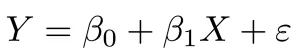


**Traitements réalisés** :<br>
<font size="2">
* Création d'une base de données
* Splitting de la base de données
* Visualisation de la base de donnée
* Choix de modèle (Linèaire)
* Spécification de la fonction coût
* Implémentation de l'algorithme d'optimisation(Descente de gradient)
* Apprentissage du modèle sur l'ensemble d'apprentisage
* Evaluation du modèle par la méthode d'analyse de la variance(Ensemble de test)
</font>


# <font color="red" size="4"><b>1. Création d'une base de données</font>


In [ ]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt


In [ ]:
n_observations=50
x,y=make_regression(n_samples=n_observations,n_features=1, noise=10)
y=y.reshape(n_observations,1)
print(np.shape(x))
print(y.shape)

(50, 1)
(50, 1)


 <font color="blue" size="3">a. Spiliting de la base de données en deux sous-ensembles(Apprentissage et Test)</font>

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

 <font color="blue" size="3">b. Visualisation des deux sous-ensembles(Apprentissage et Test)</font>

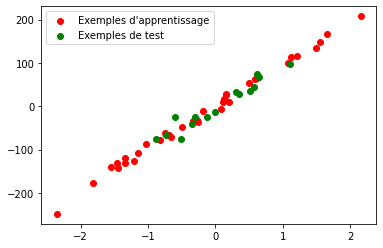

In [ ]:
plt.scatter(x_train,y_train, c='r',label="Exemples d'apprentissage")
plt.scatter(x_test,y_test, c='green',label='Exemples de test')
plt.legend()

# <font color="red" size="4"><b>2. Choix de modèle</font>


image.png


<font color="blue" size="3">a. Spécification des élements du modèle</font>

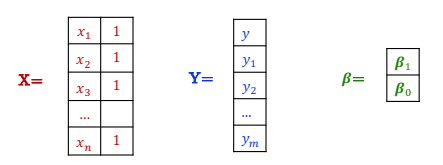

In [ ]:
n=np.shape(x_train)[0]
vecteur_unitaire=np.ones((n,1))

X_tr=np.hstack((x_train,vecteur_unitaire))

beta=np.random.randn(2,1)

print(X_tr.shape)
print(beta.shape)

(35, 2)
(2, 1)


In [ ]:
def modele(X,beta):
  return X.dot(beta)

<font color="blue" size="3">b. Visualisation des données avec le modèle de régression avant l'apprentissage</font>

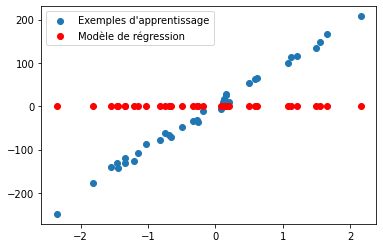

In [ ]:
y_pred=modele(X_tr,beta)
plt.scatter(x_train,y_train,label="Exemples d'apprentissage")
plt.scatter(x_train,y_pred,c='r',label="Modèle de régression")
plt.legend()

# <font color="red" size="4"><b>3. Spécification de la fonction coût</font>

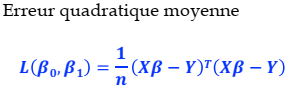

In [ ]:
def cost_function(X,y,beta):
  n=len(y)
  u=X.dot(beta)-y
  return (1/n)*u.T.dot(u)


# <font color="red" size="4"><b>4. Implémentation de l'algorithme d'optimisation pour touver les paramètres du modèle (Descente de gradient) </font>



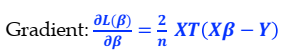

In [ ]:
def gradient(X,beta,y):
  n=len(y)
  u=X.T
  v=X.dot(beta)-y
  return (2/n)*u.dot(v)

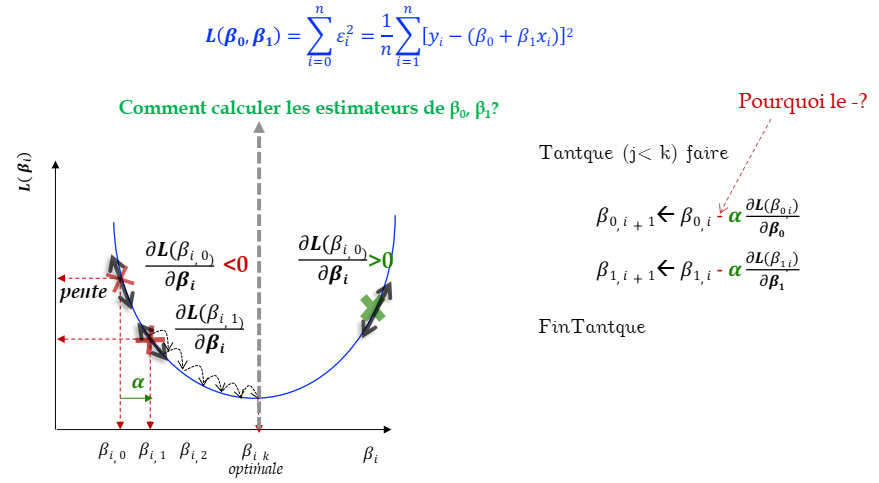

In [ ]:
def descente_gradient(X,beta,y,learning_rate=0.01, n_iterations=1000):
  cost=[]
  for i in range(n_iterations):
    beta=beta-learning_rate*gradient(X,beta,y)
    cost.append(cost_function(X,y,beta)[0])
  return beta,cost


# <font color="red" size="4"><b>5. Apprentissage du modèle sur l'ensemble d'apprentisage </font>
* Evaluation du modèle par la méthode d'analyse de la variance(Ensemble de test)


In [ ]:
beta_estimer,cost=descente_gradient(X_tr,beta,y_train ,learning_rate=0.01, n_iterations=2000)

print(beta_estimer)

[[97.15996317]
 [ 0.7516492 ]]


<font color="blue" size="3">a. Visualisation des données avec le modèle de régression après la phase d'apprentissage</font>

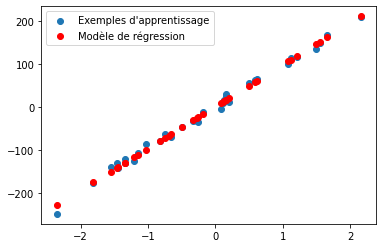

In [ ]:
y_pred=modele(X_tr,beta_estimer)
plt.scatter(x_train,y_train,label="Exemples d'apprentissage")
plt.scatter(x_train,y_pred,c='r',label="Modèle de régression")
plt.legend()

<font color="blue" size="3">b. Visualisation de l'opération d'apprentissage en fonction du nombre d'itérations et l'erreur engendrée par le modèle (Courbe d'apprentissage)</font>

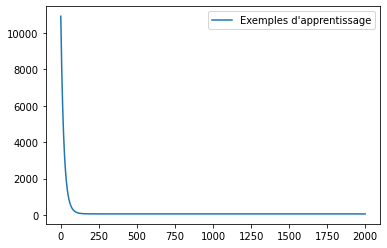

In [ ]:
plt.plot(range(0,2000),cost,label="Exemples d'apprentissage")

plt.legend()

# <font color="red" size="4"><b>6. Evaluation du modèle sur l'ensemble de test par la méthode d'analyse de la variance </font>

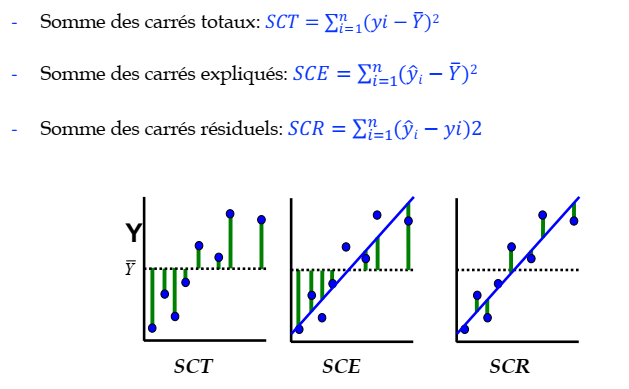

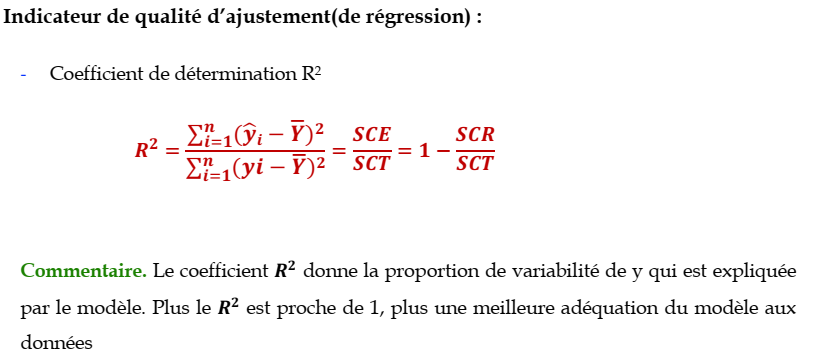

In [ ]:
n_t=np.shape(x_test)[0]
vecteur_unitaire=np.ones((n_t,1))

X_te=np.hstack((x_test,vecteur_unitaire))

print(X_te.shape)


(15, 2)


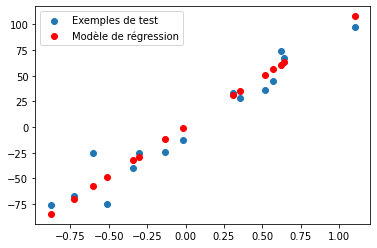

In [ ]:
y_pred_t=modele(X_te,beta_estimer)
plt.scatter(x_test,y_test,label="Exemples de test")
plt.scatter(x_test,y_pred_t,c='r',label="Modèle de régression")
plt.legend()

In [ ]:

def coefficient_determination(y,y_pr):
  SCT=((y-y.mean())**2).sum()
  SCR=((y_pr-y)**2).sum()

  return 1- (SCR/SCT)

coefficient_determination(y_test,y_pred_t)


0.9342369545235297